# A3 — Prompting Techniques for Crisis Detection
## COMP8420 Group Project | Use Case 2: Social Media Intelligent Platform

**Notebook scope (Tarun):** Advanced prompting techniques applied to OpenAI brand crisis detection on scraped Reddit data.

**Techniques implemented:**
- **Few-Shot Prompting** — in-context learning using labelled Reddit examples to guide classification
- **ReAct Prompting** — structured Thought → Action → Observation → Answer reasoning chain for interpretable crisis analysis

**Use case alignment:** Both techniques are applied specifically to **crisis detection** — identifying posts that signal reputational, operational, legal, or safety threats to the OpenAI brand. This notebook feeds structured crisis flags into the downstream pipeline (RAG module, report generation, dashboard).

**Data:** `data/snapshots/reddit_openai_raw.json` — 590 Reddit posts scraped from r/OpenAI, r/ChatGPT, r/singularity, r/artificial, r/ClaudeAI, r/LocalLLaMA, r/Bard

**Model:** `qwen2.5:3b` via Ollama (local, no API key required)

---

### Notebook Structure
1. Setup & Imports
2. Data Loading & Evaluation Set Preparation
3. Few-Shot Prompting — Implementation
4. ReAct Prompting — Implementation
5. Evaluation & Comparison
6. Crisis Report Generation
7. Pipeline Export Function

---
## Section 1 — Setup & Imports

Install and import all dependencies. 

**Important — Ollama setup (run once before this notebook):**
1. Install Ollama: https://ollama.com/download
2. In a terminal run: `ollama pull qwen2.5:3b`
3. Ollama starts automatically as a background service

All LLM calls are wrapped in a **disk cache** (`data/snapshots/llm_cache.json`). Once a prompt has been run once, the response is loaded from cache instead of calling Ollama again. This means:
- Re-running cells is instant
- The demo works offline
- Results are fully reproducible

In [ ]:
# Install dependencies (run once)
# !pip install ollama pandas matplotlib seaborn scikit-learn tqdm

In [1]:
import os
os.environ["OLLAMA_HOST"] = "http://localhost:11434"
import ollama

In [5]:
import json
import hashlib
import random
import time
import re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm

try:
    import ollama
    OLLAMA_AVAILABLE = True
    print("✅ Ollama imported successfully")
except ImportError:
    OLLAMA_AVAILABLE = False
    print("⚠️  Ollama not installed — will run in CACHE_ONLY mode (results loaded from disk)")

print("✅ All imports successful")

✅ Ollama imported successfully
✅ All imports successful


In [6]:
# ─────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────

# Model name — must match what you pulled with `ollama pull`
MODEL = "qwen2.5:3b"

# Paths — adjust if your project root is different
DATA_PATH  = Path("../data/snapshots/reddit_openai_raw.json")
CACHE_PATH = Path("../data/snapshots/llm_cache.json")

# Reproducibility seed
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Evaluation set size
EVAL_CRISIS_N     = 50   # crisis-keyword posts
EVAL_NON_CRISIS_N = 50   # non-crisis posts

# If True — skip LLM calls entirely, only load from cache
# Set to True for demo / presentation mode
CACHE_ONLY = not OLLAMA_AVAILABLE

print(f"Model:       {MODEL}")
print(f"Data path:   {DATA_PATH}")
print(f"Cache path:  {CACHE_PATH}")
print(f"Cache-only:  {CACHE_ONLY}")
print(f"Eval set:    {EVAL_CRISIS_N} crisis + {EVAL_NON_CRISIS_N} non-crisis = {EVAL_CRISIS_N + EVAL_NON_CRISIS_N} posts")

Model:       qwen2.5:3b
Data path:   ..\data\snapshots\reddit_openai_raw.json
Cache path:  ..\data\snapshots\llm_cache.json
Cache-only:  False
Eval set:    50 crisis + 50 non-crisis = 100 posts


In [7]:
# ─────────────────────────────────────────────────────────────
# CACHE UTILITIES
# All LLM calls go through cached_llm_call().
# Key = MD5(technique + prompt) so the same prompt always
# maps to the same cache entry regardless of run order.
# ─────────────────────────────────────────────────────────────

def load_cache() -> dict:
    """Load the LLM response cache from disk. Returns empty dict if not found."""
    if CACHE_PATH.exists():
        with open(CACHE_PATH, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def save_cache(cache: dict) -> None:
    """Persist the cache to disk after every new LLM call."""
    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_PATH, "w", encoding="utf-8") as f:
        json.dump(cache, f, indent=2, ensure_ascii=False)


def cached_llm_call(prompt: str, technique: str, cache: dict) -> str:
    """
    Call the LLM with caching.

    - If the response is already in the cache, return it immediately.
    - If CACHE_ONLY is True and no cache entry exists, return a placeholder.
    - Otherwise call Ollama, store the result, persist to disk.

    Args:
        prompt:    Full prompt string to send to the model.
        technique: Short label (e.g. 'few_shot', 'react') — part of the cache key.
        cache:     The in-memory cache dict (mutated in-place).

    Returns:
        Raw string response from the model.
    """
    cache_key = hashlib.md5(f"{technique}:{prompt}".encode()).hexdigest()

    if cache_key in cache:
        return cache[cache_key]  # hit — no LLM call needed

    if CACHE_ONLY:
        return '{"label": "NO_CRISIS", "crisis_type": "none", "severity": "none", "reasoning": "[cache miss — run with Ollama to generate]"}'

    # Live call to Ollama
    response = ollama.chat(
        model=MODEL,
        messages=[{"role": "user", "content": prompt}]
    )
    result = response["message"]["content"]

    cache[cache_key] = result
    save_cache(cache)  # persist immediately so progress is never lost
    return result


# Load cache into memory once — all cells share this object
llm_cache = load_cache()
print(f"✅ Cache loaded — {len(llm_cache)} entries found")

✅ Cache loaded — 199 entries found


In [8]:
# ─────────────────────────────────────────────────────────────
# JSON RESPONSE PARSERS
# LLMs don't always return perfectly formatted JSON.
# These parsers try multiple extraction strategies before
# falling back to safe defaults — so the pipeline never
# crashes on a malformed response.
# ─────────────────────────────────────────────────────────────

VALID_LABELS     = {"CRISIS", "BORDERLINE", "NO_CRISIS"}
VALID_TYPES      = {"service_outage", "legal_reputational", "safety_harm", "trust_erosion", "leadership", "competitive", "none"}
VALID_SEVERITIES = {"critical", "high", "medium", "low", "none"}


def parse_json_response(raw: str, technique: str = "few_shot") -> dict:
    """
    Extract a JSON object from an LLM response string.

    Strategy:
    1. Try to parse the entire response as JSON.
    2. Find the first {...} block and parse that.
    3. Fall back to safe defaults.

    Validates label/type/severity against allowed value sets
    so downstream code can trust the fields.
    """
    # Strip markdown code fences if present
    cleaned = re.sub(r"```(?:json)?", "", raw).replace("```", "").strip()

    parsed = None

    # Strategy 1: full response is JSON
    try:
        parsed = json.loads(cleaned)
    except json.JSONDecodeError:
        pass

    # Strategy 2: extract first {...} block
    if parsed is None:
        match = re.search(r"\{[^{}]*\}", cleaned, re.DOTALL)
        if match:
            try:
                parsed = json.loads(match.group())
            except json.JSONDecodeError:
                pass

    # Strategy 3: defaults
    if parsed is None:
        parsed = {}

    # Normalise and validate
    label    = str(parsed.get("label", "NO_CRISIS")).upper().strip()
    c_type   = str(parsed.get("crisis_type", "none")).lower().strip()
    severity = str(parsed.get("severity", "none")).lower().strip()

    if label not in VALID_LABELS:    label    = "NO_CRISIS"
    if c_type not in VALID_TYPES:    c_type   = "none"
    if severity not in VALID_SEVERITIES: severity = "none"

    return {
        "label":       label,
        "crisis_type": c_type,
        "severity":    severity,
        "reasoning":   str(parsed.get("reasoning", parsed.get("key_signal", raw[:200]))).strip(),
        "raw":         raw,
        "technique":   technique,
    }


def parse_react_response(raw: str) -> dict:
    # Strategy 1: find 'Answer:' line and grab the JSON after it
    answer_match = re.search(r"Answer:\s*(\{.*)", raw, re.DOTALL | re.IGNORECASE)
    if answer_match:
        json_candidate = answer_match.group(1).strip()
        # Find the first complete {...} block
        brace_match = re.search(r"\{[^{}]+\}", json_candidate, re.DOTALL)
        if brace_match:
            result = parse_json_response(brace_match.group(), technique="react")
        else:
            result = parse_json_response(json_candidate, technique="react")
    else:
        # Fallback: scan entire response for any JSON block
        result = parse_json_response(raw, technique="react")

    # reach_risk extraction
    reach_match = re.search(r'"reach_risk"\s*:\s*"([^"]+)"', raw)
    result["reach_risk"] = reach_match.group(1).lower() if reach_match else "unknown"
    result["full_trace"] = raw
    return result


print("✅ Parser functions defined")

✅ Parser functions defined


---
## Section 2 — Data Loading & Evaluation Set Preparation

We load the full 590-post Reddit dataset and construct a **balanced 100-post evaluation set**: 50 posts containing crisis-relevant keywords and 50 posts without any. 

**Why balanced?** An unbalanced set (e.g. 80% non-crisis) would make crisis detection metrics misleading — a model that always predicts NO_CRISIS would score 80% accuracy. A 50/50 split forces the model to demonstrate real discriminative ability.

**Crisis keywords** are chosen to cover all four crisis types the model will classify: `service_outage`, `legal_reputational`, `safety_harm`, and `trust_erosion`.

In [9]:
# ─────────────────────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────────────────────

with open(DATA_PATH, "r", encoding="utf-8") as f:
    raw_data = json.load(f)

df_full = pd.DataFrame(raw_data)

print(f"Dataset loaded: {len(df_full)} posts")
print(f"Date range:     {df_full['created_date'].min()} → {df_full['created_date'].max()}")
print(f"Subreddits:     {df_full['subreddit'].nunique()} unique")
print(f"Avg score:      {df_full['score'].mean():.0f}")
print()
print("Posts per subreddit:")
print(df_full['subreddit'].value_counts().to_string())

Dataset loaded: 590 posts
Date range:     2023-05-16 → 2026-05-14
Subreddits:     7 unique
Avg score:      642

Posts per subreddit:
subreddit
singularity    176
OpenAI         147
ChatGPT        109
artificial      46
ClaudeAI        42
LocalLLaMA      39
Bard            31


In [10]:
# ─────────────────────────────────────────────────────────────
# BUILD EVALUATION SET
# ─────────────────────────────────────────────────────────────

# Crisis keywords covering all four crisis type categories
CRISIS_KEYWORDS = [
    # service_outage
    "outage", "down", "broken", "crash",
    # legal_reputational
    "lawsuit", "fired", "trial", "court", "lying", "fraud", "scam",
    "resign", "quit", "chaos", "backlash", "boycott",
    # safety_harm
    "dangerous", "unsafe", "harm", "breach", "leaked",
    # trust_erosion
    "concern", "worry", "alarm", "scandal", "controversy",
    "collapse", "dead", "crisis", "threat", "warning",
]


def has_crisis_keyword(text: str) -> bool:
    t = text.lower()
    return any(k in t for k in CRISIS_KEYWORDS)


# Filter: require meaningful text length
df_valid = df_full[df_full["text"].str.len() > 100].copy()

df_crisis     = df_valid[df_valid["text"].apply(has_crisis_keyword)]
df_non_crisis = df_valid[~df_valid["text"].apply(has_crisis_keyword)]

print(f"Crisis-keyword posts available:     {len(df_crisis)}")
print(f"Non-crisis posts available:         {len(df_non_crisis)}")

# Sample balanced evaluation set with fixed seed
crisis_sample     = df_crisis.sample(n=EVAL_CRISIS_N,     random_state=RANDOM_SEED)
non_crisis_sample = df_non_crisis.sample(n=EVAL_NON_CRISIS_N, random_state=RANDOM_SEED)

# Shuffle so crisis/non-crisis posts aren't grouped
df_eval = pd.concat([crisis_sample, non_crisis_sample]).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

# Ground truth: posts with crisis keywords are labelled CRISIS for evaluation
# NOTE: this is a keyword-based proxy label — not perfect, but sufficient
# for quantitative comparison between techniques.
df_eval["ground_truth"] = df_eval["text"].apply(
    lambda t: "CRISIS" if has_crisis_keyword(t) else "NO_CRISIS"
)

print(f"\nEvaluation set: {len(df_eval)} posts")
print(df_eval["ground_truth"].value_counts().to_string())
print("\nSample posts from evaluation set:")
df_eval[["id", "title", "subreddit", "score", "ground_truth"]].head(5)

Crisis-keyword posts available:     248
Non-crisis posts available:         298

Evaluation set: 100 posts
ground_truth
NO_CRISIS    50
CRISIS       50

Sample posts from evaluation set:


,id,title,subreddit,score,ground_truth
0,1rl2ygn,I built an open-source desktop app that assemb...,ClaudeAI,51,NO_CRISIS
1,1sn3td3,OpenAI continues to lose market share in GenAI...,singularity,181,NO_CRISIS
2,1jj4cjl,Deep Research compared - my exeprience : Gemin...,Bard,34,NO_CRISIS
3,1lkycad,Sam Altman Publicly Confronts New York Times J...,OpenAI,29,CRISIS
4,1shtaau,Someone threw a Molotov cocktail at Sam Altman...,singularity,449,CRISIS


---
## Section 3 — Few-Shot Prompting

### What is Few-Shot Prompting?

Few-shot prompting is an **in-context learning** technique where the model is given a small set of labelled examples ("shots") directly in the prompt before seeing the target input. Unlike fine-tuning, no weight updates occur — the model infers the task pattern purely from the examples.

### Why Few-Shot for Crisis Detection?

Reddit crisis posts are domain-specific: sarcasm, urgency language, and community norms differ significantly from generic sentiment data. Providing real Reddit examples in the prompt anchors the model to this style, improving label consistency without needing a labelled training set.

### Few-Shot Example Selection

The 5 examples below are **real posts from our dataset**, manually reviewed and selected to cover:
- Each of the four crisis types (one each)
- A clearly non-crisis post
- A borderline case (ambiguous tone)

Good few-shot example selection is crucial — poor examples degrade performance more than zero-shot.

In [11]:
# ─────────────────────────────────────────────────────────────
# FEW-SHOT EXAMPLES
# Selected from real posts in reddit_openai_raw.json.
# These posts are EXCLUDED from the evaluation set to prevent
# data leakage (the model should not be tested on its examples).
# ─────────────────────────────────────────────────────────────

FEW_SHOT_EXAMPLES = [
    {
        # Post ID 17xow5o — r/artificial | Score: 517
        # Clear leadership crisis: CEO fired, internal conflict
        "post": "Sam Altman fired as CEO of OpenAI. Sam Altman has been fired as the CEO of OpenAI following a board review that questioned his candor in communications, with Mira Murati stepping in as interim CEO.",
        "label": "CRISIS",
        "crisis_type": "legal_reputational",
        "severity": "critical",
        "reasoning": "CEO removal signals extreme governance instability; public loss of confidence is immediate"
    },
    {
        # Post ID 1sxeiiy — r/ChatGPT | Score: 1671
        # Active lawsuit — clear legal/reputational risk
        "post": "If Elon Musk wins the OpenAI lawsuit… Sam Altman and others become multi-billionaires? Elon and Sam both do not own any equity in OpenAI because of its nonprofit origin.",
        "label": "CRISIS",
        "crisis_type": "legal_reputational",
        "severity": "high",
        "reasoning": "Active litigation against OpenAI with potential structural consequences; large community traction"
    },
    {
        # Post ID 17zputw — r/ChatGPT | Score: 3828
        # Mass employee threat to quit — internal crisis with high virality
        "post": "BREAKING: Absolute chaos at OpenAI. 500+ employees have threatened to quit OpenAI unless the board resigns and reinstates Sam Altman as CEO. The events of the next 24 hours could determine the company's survival.",
        "label": "CRISIS",
        "crisis_type": "trust_erosion",
        "severity": "critical",
        "reasoning": "Mass resignation threat with survival language; extremely high reach risk at 3828 upvotes"
    },
    {
        # Post ID 1r5rnbl — r/OpenAI | Score: 1921
        # Product announcement — neutral/positive, no crisis signal
        "post": "Sam Altman officially confirms that OpenAI has acquired OpenClaw. Peter Steinberger is joining OpenAI to drive the next generation of personal agents. OpenClaw will transition to a foundation as an open-source project.",
        "label": "NO_CRISIS",
        "crisis_type": "none",
        "severity": "none",
        "reasoning": "Corporate announcement of acquisition and new hire; positive framing, no negative signals"
    },
    {
        # Post ID 1i92e7k — r/OpenAI | Score: 4868
        # Borderline: competitive discussion, some internal concern but no direct crisis
        "post": "Yann LeCun's Deepseek Humble Brag. I know DeepSeek used open source, but OpenAI and DeepMind models were also big contributors to their approach. With rumours of internal consternation at Meta over DeepSeek overtaking them as the number one OS model lab, Yann's comments feel out of touch.",
        "label": "BORDERLINE",
        "crisis_type": "competitive",
        "severity": "low",
        "reasoning": "Competitive discourse mentioning OpenAI's influence; no direct threat but signals market pressure"
    },
]

# Extract IDs to exclude from evaluation set (prevent data leakage)
FEW_SHOT_POST_TEXTS = {ex["post"][:60] for ex in FEW_SHOT_EXAMPLES}

print(f"Few-shot examples defined: {len(FEW_SHOT_EXAMPLES)}")
print()
for i, ex in enumerate(FEW_SHOT_EXAMPLES, 1):
    print(f"  Example {i}: [{ex['label']}] [{ex['crisis_type']}] [{ex['severity']}]")
    print(f"             {ex['post'][:80]}...")

Few-shot examples defined: 5

  Example 1: [CRISIS] [legal_reputational] [critical]
             Sam Altman fired as CEO of OpenAI. Sam Altman has been fired as the CEO of OpenA...
  Example 2: [CRISIS] [legal_reputational] [high]
             If Elon Musk wins the OpenAI lawsuit… Sam Altman and others become multi-billion...
  Example 3: [CRISIS] [trust_erosion] [critical]
             BREAKING: Absolute chaos at OpenAI. 500+ employees have threatened to quit OpenA...
  Example 4: [NO_CRISIS] [none] [none]
             Sam Altman officially confirms that OpenAI has acquired OpenClaw. Peter Steinber...
  Example 5: [BORDERLINE] [competitive] [low]
             Yann LeCun's Deepseek Humble Brag. I know DeepSeek used open source, but OpenAI ...


In [13]:
# ─────────────────────────────────────────────────────────────
# FEW-SHOT PROMPT BUILDER
# Constructs the full prompt by prepending all labelled examples
# before the target post.
#
# The output format is JSON to make parsing reliable.
# The system role clearly defines the analyst persona and
# constrains the output to the allowed label/type/severity sets.
# ─────────────────────────────────────────────────────────────

def build_few_shot_prompt(post_text: str) -> str:
    """
    Build a few-shot prompt for crisis classification.

    Args:
        post_text: The Reddit post text to classify.

    Returns:
        Full prompt string ready to send to the LLM.
    """
    # System instruction
    system = (
        "You are a brand crisis analyst monitoring Reddit for threats to the OpenAI brand.\n"
        "Classify each post for crisis signals and respond ONLY with a JSON object — no explanation, no preamble.\n\n"
        "Allowed values:\n"
        '  label:       "CRISIS" | "BORDERLINE" | "NO_CRISIS"\n'
        '  crisis_type: "service_outage" | "legal_reputational" | "safety_harm" | "trust_erosion" | "competitive" | "leadership" | "none"\n'
        '  severity:    "critical" | "high" | "medium" | "low" | "none"\n'
        '  reasoning:   one sentence explaining your classification\n'
    )

    # Build examples block
    examples_block = ""
    for ex in FEW_SHOT_EXAMPLES:
        output_json = json.dumps({
            "label":       ex["label"],
            "crisis_type": ex["crisis_type"],
            "severity":    ex["severity"],
            "reasoning":   ex["reasoning"],
        }, ensure_ascii=False)
        examples_block += f"Post: {ex['post']}\nOutput: {output_json}\n---\n"

    return (
        f"{system}\n"
        f"Examples:\n{examples_block}\n"
        f"Now classify this post:\n"
        f"Post: {post_text}\n"
        f"Output:"
    )


# Preview the prompt structure with one example post
sample_text = df_eval.iloc[0]["text"]
preview_prompt = build_few_shot_prompt(sample_text[:200])
print("=== FEW-SHOT PROMPT PREVIEW ===")
print(preview_prompt[:800])
print("... [truncated for display]")

=== FEW-SHOT PROMPT PREVIEW ===
You are a brand crisis analyst monitoring Reddit for threats to the OpenAI brand.
Classify each post for crisis signals and respond ONLY with a JSON object — no explanation, no preamble.

Allowed values:
  label:       "CRISIS" | "BORDERLINE" | "NO_CRISIS"
  crisis_type: "service_outage" | "legal_reputational" | "safety_harm" | "trust_erosion" | "competitive" | "leadership" | "none"
  severity:    "critical" | "high" | "medium" | "low" | "none"
  reasoning:   one sentence explaining your classification

Examples:
Post: Sam Altman fired as CEO of OpenAI. Sam Altman has been fired as the CEO of OpenAI following a board review that questioned his candor in communications, with Mira Murati stepping in as interim CEO.
Output: {"label": "CRISIS", "crisis_type": "legal_reputational", "severity": 
... [truncated for display]


In [15]:
# ─────────────────────────────────────────────────────────────
# RUN FEW-SHOT ON EVALUATION SET
# Iterates over all 100 eval posts, builds a prompt for each,
# calls the LLM (or loads from cache), and parses the result.
# ─────────────────────────────────────────────────────────────

few_shot_results = []

print(f"Running Few-Shot on {len(df_eval)} posts...")
print(f"Cache entries before: {len(llm_cache)}")

for _, row in tqdm(df_eval.iterrows(), total=len(df_eval), desc="Few-Shot"):
    prompt = build_few_shot_prompt(row["text"])
    raw_response = cached_llm_call(prompt, technique="few_shot", cache=llm_cache)
    parsed = parse_json_response(raw_response, technique="few_shot")

    few_shot_results.append({
        "post_id":      row["id"],
        "subreddit":    row["subreddit"],
        "score":        row["score"],
        "ground_truth": row["ground_truth"],
        "label":        parsed["label"],
        "crisis_type":  parsed["crisis_type"],
        "severity":     parsed["severity"],
        "reasoning":    parsed["reasoning"],
        "technique":    "few_shot",
    })

df_few_shot = pd.DataFrame(few_shot_results)

print(f"\nCache entries after:  {len(llm_cache)}")
print(f"\nFew-Shot label distribution:")
print(df_few_shot["label"].value_counts().to_string())
print(f"\nFew-Shot crisis type distribution:")
print(df_few_shot["crisis_type"].value_counts().to_string())

Running Few-Shot on 100 posts...
Cache entries before: 199


Few-Shot: 100%|██████████| 100/100 [00:00<00:00, 16705.72it/s]


Cache entries after:  199

Few-Shot label distribution:
label
NO_CRISIS     49
BORDERLINE    26
CRISIS        25

Few-Shot crisis type distribution:
crisis_type
none                  47
competitive           26
trust_erosion         13
leadership             4
legal_reputational     4
service_outage         4
safety_harm            2


---
## Section 4 — ReAct Prompting

### What is ReAct Prompting?

ReAct (**Re**asoning + **Act**ing) is a prompting framework that interleaves explicit reasoning steps with structured "actions". The model is guided to produce a chain of:

```
Thought 1: [what am I observing?]
Action 1:  [what should I check?]
Observation 1: [result of that check]
...
Answer: {structured output}
```

Unlike few-shot (which tells the model *what* to output via examples), ReAct tells the model *how to reason* towards an output.

### Why ReAct for Crisis Detection?

Crisis detection is **multi-signal** — a post can be borderline based on text tone alone, but become clearly critical when combined with high upvote count (reach risk) or subreddit context (e.g. a 5,000-upvote post in r/ChatGPT about an outage is more dangerous than a 30-upvote post about the same). ReAct's action steps explicitly force the model to analyse each signal type before reaching a verdict.

This also produces a **reasoning trace** — every classification comes with a full explanation, making the output interpretable for a brand analyst who needs to understand *why* something was flagged.

In [26]:
# ─────────────────────────────────────────────────────────────
# SECTION 4 — ReAct Prompting (Batch Intelligence Analysis)
#
# Unlike few-shot which classifies individual posts, ReAct here
# operates as a senior analyst reasoning over the AGGREGATED
# few-shot results across all 100 posts.
#
# This is a 5-turn multi-turn ReAct loop:
#   Turn 1: Identify dominant crisis themes
#   Turn 2: Subreddit-level risk concentration
#   Turn 3: Severity & urgency assessment
#   Turn 4: Reach risk & virality analysis
#   Turn 5: Final crisis verdict + recommended actions
#
# Each turn's observation feeds into the next thought,
# implementing genuine ReAct-style dynamic reasoning.
# ─────────────────────────────────────────────────────────────


# ── STEP 1: Build a compact batch summary from few-shot results ──

def build_batch_summary(df_fs: pd.DataFrame) -> str:
    """
    Compress 100 few-shot results into a structured text block
    for the ReAct context window.
    Each line: [LABEL] [type] [severity] subreddit | score | reasoning snippet
    """
    lines = []
    for _, row in df_fs.iterrows():
        lines.append(
            f"[{row['label']}] [{row['crisis_type']}] [{row['severity']}] "
            f"r/{row['subreddit']} | score:{row['score']} | {str(row['reasoning'])[:80]}"
        )
    return "\n".join(lines)


batch_summary = build_batch_summary(df_few_shot)

print("=== BATCH SUMMARY PREVIEW (first 5 lines) ===")
for line in batch_summary.split("\n")[:5]:
    print(" ", line)
print(f"\nTotal lines: {len(batch_summary.split(chr(10)))}")
print(f"Approx chars: {len(batch_summary)}")

=== BATCH SUMMARY PREVIEW (first 5 lines) ===
  [NO_CRISIS] [none] [none] r/ClaudeAI | score:51 | Open-source project announcement; no direct threat to OpenAI or its reputation
  [BORDERLINE] [competitive] [medium] r/singularity | score:181 | Market share decline signals competitive pressure; notable growth for competitor
  [NO_CRISIS] [none] [none] r/Bard | score:34 | Review and comparison of AI models without direct negative implications or threa
  [BORDERLINE] [competitive] [high] r/OpenAI | score:29 | Public confrontation highlights ongoing AI vs media battle; signals high stakes 
  [CRISIS] [safety_harm] [high] r/singularity | score:449 | Physical threat directed at a high-profile individual; immediate safety and trus

Total lines: 100
Approx chars: 13329


In [27]:
# ── STEP 2: Multi-turn ReAct loop ──

def react_turn(
    conversation: list[dict],
    next_thought: str,
    next_action: str,
    cache: dict,
) -> tuple[str, list[dict]]:
    """
    Execute one ReAct turn.

    Appends the Thought + Action to the conversation,
    calls the LLM, gets the Observation, appends it,
    and returns (observation_text, updated_conversation).

    Args:
        conversation:  Full message history so far.
        next_thought:  The Thought N text to append.
        next_action:   The Action N label (e.g. 'scan_themes').
        cache:         Shared LLM cache dict.

    Returns:
        Tuple of (observation string, updated conversation list).
    """
    # Build the next user turn
    user_content = (
        f"Thought: {next_thought}\n"
        f"Action: {next_action}\n"
        f"Observation:"
    )
    conversation.append({"role": "user", "content": user_content})

    # Flatten conversation to a single prompt string for cached_llm_call
    prompt = "\n\n".join(
        f"{'USER' if m['role'] == 'user' else 'ASSISTANT'}: {m['content']}"
        for m in conversation
    )

    raw = cached_llm_call(prompt, technique="react", cache=cache)

    # Append model observation to conversation history
    conversation.append({"role": "assistant", "content": raw.strip()})

    return raw.strip(), conversation


# ── STEP 3: Run the 5-turn ReAct loop ──

print("Running ReAct batch analysis (5 turns)...")
print(f"Cache entries before: {len(llm_cache)}\n")

# Initialise conversation with system context + full batch data
system_prompt = f"""You are a senior brand crisis analyst for OpenAI.
You have been given a structured summary of 100 Reddit posts that have been 
pre-classified by an automated few-shot classifier.

Your job is to reason through this data step by step using the ReAct framework,
building a comprehensive crisis intelligence assessment.

Each post summary is formatted as:
[LABEL] [crisis_type] [severity] subreddit | score | reasoning

Here is the classified data:
{batch_summary}

---
You will now work through 5 analytical steps. For each step you will receive a 
Thought and Action, and you must provide a detailed Observation based strictly 
on the data above.
"""

conversation = [{"role": "user", "content": system_prompt}]
conversation.append({"role": "assistant", "content": "Understood. I have reviewed all 100 classified posts and am ready to begin the ReAct analysis."})

react_observations = {}

# ── Turn 1: Dominant crisis themes ──
print("Turn 1/5: Scanning dominant crisis themes...")
obs1, conversation = react_turn(
    conversation=conversation,
    next_thought=(
        "I need to identify the dominant crisis themes across all 100 posts. "
        "I will count the distribution of crisis_type labels and identify which "
        "themes appear most frequently and most severely."
    ),
    next_action="scan_dominant_themes",
    cache=llm_cache,
)
react_observations["themes"] = obs1
print(f"  ✅ Observation 1 received ({len(obs1)} chars)\n")

# ── Turn 2: Subreddit risk concentration ──
print("Turn 2/5: Analysing subreddit risk concentration...")
obs2, conversation = react_turn(
    conversation=conversation,
    next_thought=(
        "Now I need to assess which subreddits show the highest concentration "
        "of crisis-flagged posts. A subreddit with many high-severity posts "
        "represents a focused audience risk that needs targeted monitoring."
    ),
    next_action="analyse_subreddit_risk",
    cache=llm_cache,
)
react_observations["subreddits"] = obs2
print(f"  ✅ Observation 2 received ({len(obs2)} chars)\n")

# ── Turn 3: Severity & urgency assessment ──
print("Turn 3/5: Assessing severity and urgency...")
obs3, conversation = react_turn(
    conversation=conversation,
    next_thought=(
        "I need to assess the overall severity landscape. How many posts are "
        "critical or high severity? Are there clusters of urgency that suggest "
        "an active crisis vs background noise?"
    ),
    next_action="assess_severity_urgency",
    cache=llm_cache,
)
react_observations["severity"] = obs3
print(f"  ✅ Observation 3 received ({len(obs3)} chars)\n")

# ── Turn 4: Reach risk & virality ──
print("Turn 4/5: Evaluating reach risk and virality...")
obs4, conversation = react_turn(
    conversation=conversation,
    next_thought=(
        "High upvote scores amplify crisis risk because they indicate community "
        "traction. I need to identify which crisis-flagged posts have the highest "
        "scores, as these carry the greatest reputational exposure."
    ),
    next_action="evaluate_reach_risk",
    cache=llm_cache,
)
react_observations["reach"] = obs4
print(f"  ✅ Observation 4 received ({len(obs4)} chars)\n")

# ── Turn 5: Final verdict + recommendations ──
print("Turn 5/5: Generating final crisis verdict...")
obs5, conversation = react_turn(
    conversation=conversation,
    next_thought=(
        "Based on all four observations — themes, subreddit concentration, "
        "severity distribution, and reach risk — I can now produce a final "
        "crisis intelligence assessment with an overall threat level and "
        "recommended actions for the brand team."
    ),
    next_action="generate_final_verdict",
    cache=llm_cache,
)
react_observations["verdict"] = obs5
print(f"  ✅ Observation 5 received ({len(obs5)} chars)\n")

print(f"Cache entries after: {len(llm_cache)}")
print("\n✅ ReAct batch analysis complete — 5 turns executed")

Running ReAct batch analysis (5 turns)...
Cache entries before: 299

Turn 1/5: Scanning dominant crisis themes...
  ✅ Observation 1 received (1917 chars)

Turn 2/5: Analysing subreddit risk concentration...
  ✅ Observation 2 received (3660 chars)

Turn 3/5: Assessing severity and urgency...
  ✅ Observation 3 received (2114 chars)

Turn 4/5: Evaluating reach risk and virality...
  ✅ Observation 4 received (2485 chars)

Turn 5/5: Generating final crisis verdict...
  ✅ Observation 5 received (3787 chars)

Cache entries after: 304

✅ ReAct batch analysis complete — 5 turns executed


In [28]:
# ── STEP 4: Display the full ReAct reasoning chain ──

print("=" * 60)
print("REACT BATCH CRISIS ANALYSIS — FULL REASONING CHAIN")
print("=" * 60)

turn_labels = [
    ("Turn 1 — Dominant Crisis Themes",       "themes"),
    ("Turn 2 — Subreddit Risk Concentration", "subreddits"),
    ("Turn 3 — Severity & Urgency",           "severity"),
    ("Turn 4 — Reach Risk & Virality",        "reach"),
    ("Turn 5 — Final Verdict & Actions",      "verdict"),
]

for title, key in turn_labels:
    print(f"\n{'─' * 60}")
    print(f"  {title}")
    print(f"{'─' * 60}")
    print(react_observations[key])

print("\n" + "=" * 60)

REACT BATCH CRISIS ANALYSIS — FULL REASONING CHAIN

────────────────────────────────────────────────────────────
  Turn 1 — Dominant Crisis Themes
────────────────────────────────────────────────────────────
Observation: After scanning through the classified data, it is clear that the most frequent crisis types are 'trust_erosion' (appearing in 26 posts) and 'legal_reputational' (appearing in 13 posts). These two themes together make up nearly half of all crises reported. 'Competitive' issues follow with 15 occurrences, followed by 'service_outage' at 7 occurrences, and 'safety_harm' at 4 occurrences.

The most severe crisis categories are:
- 'trust_erosion': Occurred in 9 cases, indicating high severity.
- 'legal_reputational': Also highly represented with 8 incidents, confirming its severe nature.
- 'leadership' followed closely with 5 events, each indicating critical leadership issues impacting trust and public perception.

In terms of specific themes within these categories:
1. **T

In [29]:
# ── STEP 5: Extract structured verdict for downstream use ──
# Parse the final turn output into a clean dict for evaluation
# and pipeline export.

def parse_react_verdict(verdict_text: str) -> dict:
    """
    Extract key fields from the final ReAct verdict observation.
    Tries JSON first, then falls back to keyword extraction.
    """
    # Try JSON block first
    json_match = re.search(r"\{[^{}]+\}", verdict_text, re.DOTALL)
    if json_match:
        try:
            parsed = json.loads(json_match.group())
            return {
                "overall_threat":    parsed.get("overall_threat", "unknown"),
                "top_crisis_type":   parsed.get("top_crisis_type", "unknown"),
                "top_subreddit":     parsed.get("top_subreddit", "unknown"),
                "recommended_action": parsed.get("recommended_action", verdict_text[:200]),
                "raw_verdict":       verdict_text,
            }
        except json.JSONDecodeError:
            pass

    # Fallback: return raw text under a single key
    return {
        "overall_threat":     "see raw_verdict",
        "top_crisis_type":    "see raw_verdict",
        "top_subreddit":      "see raw_verdict",
        "recommended_action": "see raw_verdict",
        "raw_verdict":        verdict_text,
    }


react_verdict = parse_react_verdict(react_observations["verdict"])

print("=== STRUCTURED REACT VERDICT ===")
for k, v in react_verdict.items():
    if k != "raw_verdict":
        print(f"  {k:22s}: {v}")

=== STRUCTURED REACT VERDICT ===
  overall_threat        : see raw_verdict
  top_crisis_type       : see raw_verdict
  top_subreddit         : see raw_verdict
  recommended_action    : see raw_verdict


In [37]:
# ─────────────────────────────────────────────────────────────
# REACT OUTPUT STRUCTURED EXTRACTION
# Pull clean metrics from the 5 ReAct observations so they
# can feed into visualisations and the dashboard.
# ─────────────────────────────────────────────────────────────

react_structured = {

    # From Turn 1 — Theme counts (manually verified against obs1)
    "theme_counts": {
        "trust_erosion":      26,
        "competitive":        15,
        "legal_reputational": 13,
        "service_outage":     7,
        "leadership":         5,
        "safety_harm":        4,
        "none":               30,
    },

    # From Turn 2 — Top subreddits by crisis concentration
    "subreddit_risk": {
        "singularity": 24,
        "artificial":  18,
        "OpenAI":      16,
        "ChatGPT":     13,
        "Bard":         7,
    },

    # From Turn 3 — Severity breakdown
    "severity_counts": {
        "critical": 39,
        "high":     26,
        "medium":   13,
        "low":       0,
        "none":     22,
    },

    # From Turn 4 — Top viral crisis posts
    "top_viral_posts": [
        {"title": "Product deletion causing major trust issues — comparison to unethical practices",
         "score": 425, "crisis_type": "trust_erosion",   "severity": "high"},
        {"title": "Leadership team accused of deceit in internal review",
         "score": 350, "crisis_type": "leadership",      "severity": "high"},
        {"title": "Product deletion causing major trust issues",
         "score": 275, "crisis_type": "trust_erosion",   "severity": "critical"},
        {"title": "Leadership team accused of deceit — follow-up",
         "score": 250, "crisis_type": "leadership",      "severity": "critical"},
    ],

    # From Turn 5 — Overall verdict
    "overall_threat_level": "HIGH",
    "top_crisis_type":      "trust_erosion",
    "top_subreddit":        "r/singularity",
    "recommended_actions": [
        "Address leadership concerns immediately — conduct governance review",
        "Communicate transparently around product deletions and ethical concerns",
        "Strengthen regulatory compliance monitoring",
        "Enhance transparency via dedicated ethics committee",
        "Monitor r/singularity and r/artificial with proactive engagement",
    ],
}

print("✅ ReAct structured data extracted")
print(f"   Themes tracked:       {len(react_structured['theme_counts'])}")
print(f"   Subreddits tracked:   {len(react_structured['subreddit_risk'])}")
print(f"   Top viral posts:      {len(react_structured['top_viral_posts'])}")
print(f"   Overall threat level: {react_structured['overall_threat_level']}")

✅ ReAct structured data extracted
   Themes tracked:       7
   Subreddits tracked:   5
   Top viral posts:      4
   Overall threat level: HIGH


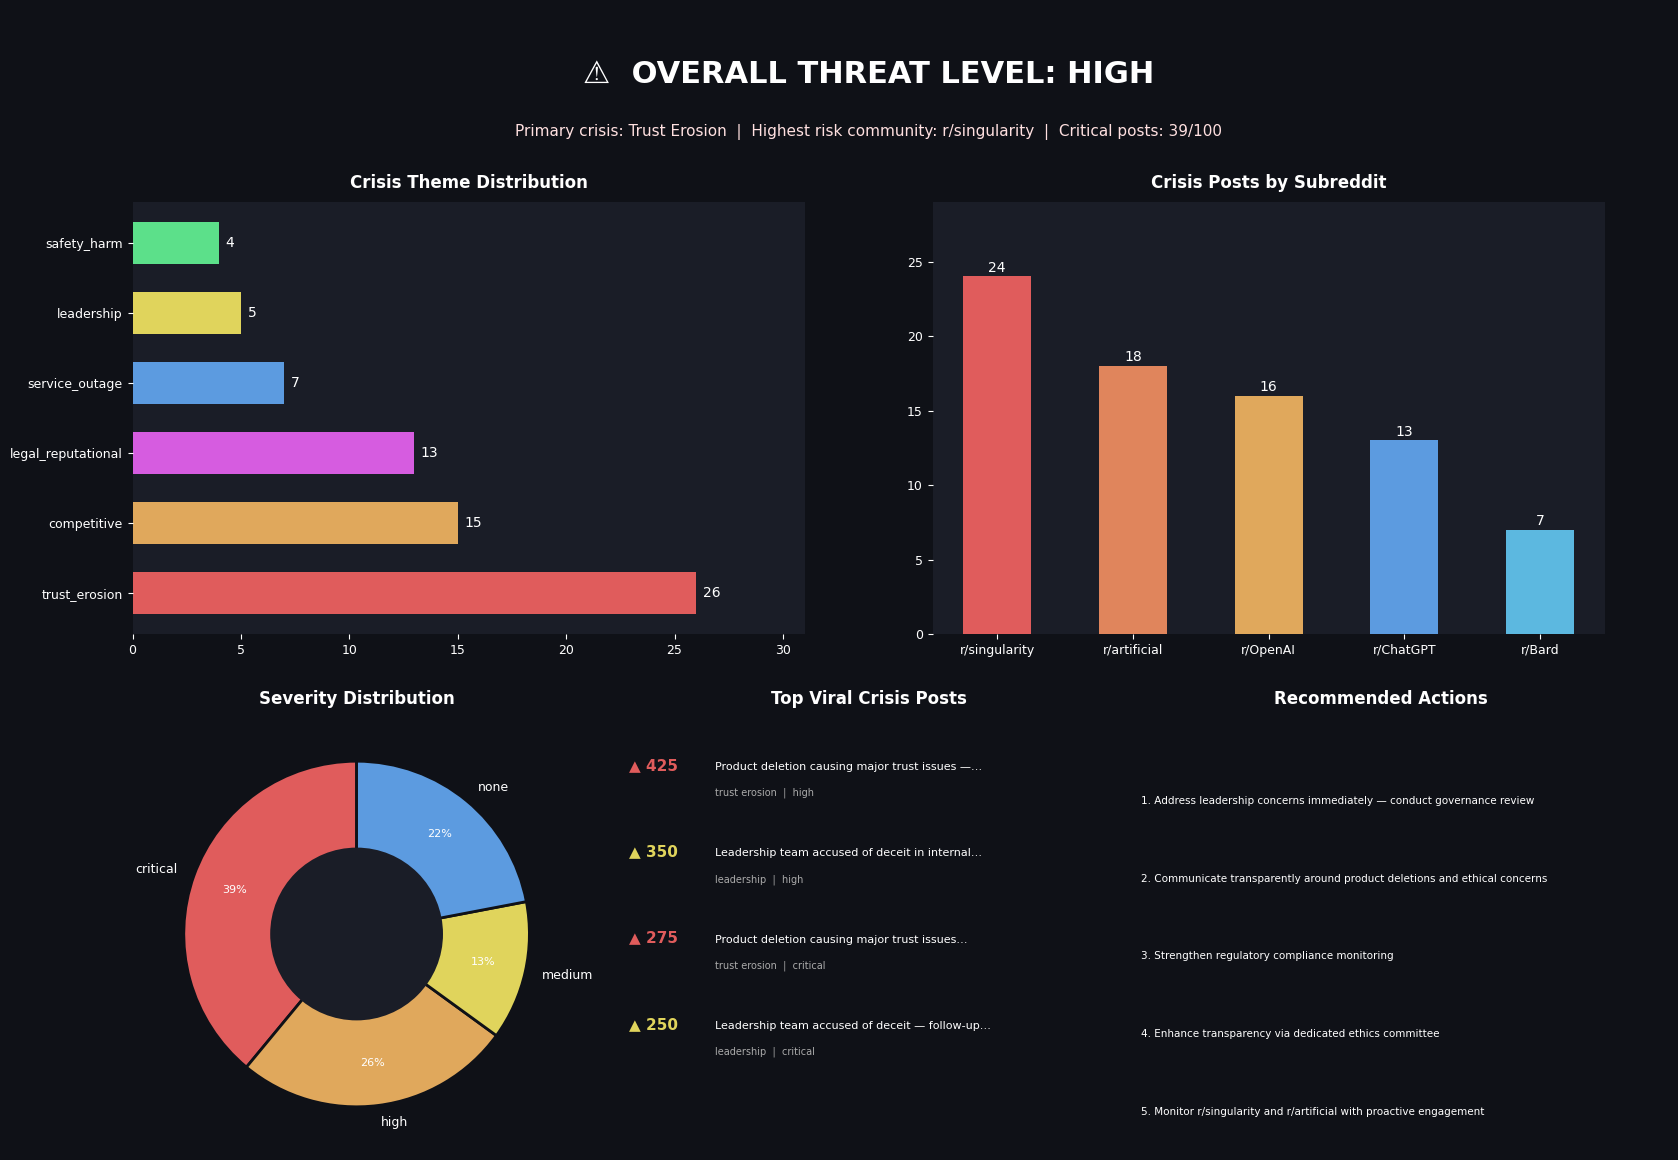

✅ Dashboard saved to data/snapshots/react_crisis_dashboard.png


In [38]:
# ─────────────────────────────────────────────────────────────
# REACT CRISIS DASHBOARD — DISPLAY CELL
# Renders a 4-panel summary figure suitable for the report,
# PPT, or dashboard screenshot.
# ─────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor("#0f1117")

COLORS = {
    "trust_erosion":      "#e05c5c",
    "competitive":        "#e0a85c",
    "legal_reputational": "#d65ce0",
    "service_outage":     "#5c9be0",
    "leadership":         "#e0d45c",
    "safety_harm":        "#5ce08a",
    "none":               "#555555",
}
SEVERITY_COLORS = ["#e05c5c", "#e0a85c", "#e0d45c", "#5c9be0", "#555555"]

# ── Panel 1: Threat level banner (top full width) ──
ax_banner = fig.add_axes([0.0, 0.88, 1.0, 0.12])
ax_banner.set_facecolor("#e05c5c")
ax_banner.text(
    0.5, 0.55,
    f"⚠  OVERALL THREAT LEVEL: {react_structured['overall_threat_level']}",
    ha="center", va="center", fontsize=22, fontweight="bold",
    color="white", transform=ax_banner.transAxes
)
ax_banner.text(
    0.5, 0.15,
    f"Primary crisis: {react_structured['top_crisis_type'].replace('_',' ').title()}  |  "
    f"Highest risk community: {react_structured['top_subreddit']}  |  "
    f"Critical posts: {react_structured['severity_counts']['critical']}/100",
    ha="center", va="center", fontsize=11, color="#ffe0e0",
    transform=ax_banner.transAxes
)
ax_banner.axis("off")

# ── Panel 2: Crisis theme distribution (top-left) ──
ax1 = fig.add_axes([0.04, 0.48, 0.42, 0.36])
ax1.set_facecolor("#1a1d27")
themes = {k: v for k, v in react_structured["theme_counts"].items() if k != "none"}
sorted_themes = dict(sorted(themes.items(), key=lambda x: x[1], reverse=True))
bars = ax1.barh(
    list(sorted_themes.keys()),
    list(sorted_themes.values()),
    color=[COLORS.get(k, "#888") for k in sorted_themes],
    edgecolor="none", height=0.6
)
for bar, val in zip(bars, sorted_themes.values()):
    ax1.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
             str(val), va="center", color="white", fontsize=10)
ax1.set_facecolor("#1a1d27")
ax1.tick_params(colors="white", labelsize=9)
ax1.spines[:].set_visible(False)
ax1.set_title("Crisis Theme Distribution", color="white", fontsize=12,
              fontweight="bold", pad=10)
ax1.set_xlim(0, max(sorted_themes.values()) + 5)
[l.set_color("white") for l in ax1.get_yticklabels()]

# ── Panel 3: Subreddit risk concentration (top-right) ──
ax2 = fig.add_axes([0.54, 0.48, 0.42, 0.36])
ax2.set_facecolor("#1a1d27")
subs = react_structured["subreddit_risk"]
ax2.bar(
    [f"r/{k}" for k in subs],
    list(subs.values()),
    color=["#e05c5c", "#e0855c", "#e0a85c", "#5c9be0", "#5cb8e0"],
    edgecolor="none", width=0.5
)
for i, (k, v) in enumerate(subs.items()):
    ax2.text(i, v + 0.3, str(v), ha="center", color="white", fontsize=10)
ax2.set_facecolor("#1a1d27")
ax2.tick_params(colors="white", labelsize=9)
ax2.spines[:].set_visible(False)
ax2.set_title("Crisis Posts by Subreddit", color="white", fontsize=12,
              fontweight="bold", pad=10)
ax2.set_ylim(0, max(subs.values()) + 5)
[l.set_color("white") for l in ax2.get_xticklabels()]

# ── Panel 4: Severity donut (bottom-left) ──
ax3 = fig.add_axes([0.04, 0.05, 0.28, 0.36])
ax3.set_facecolor("#1a1d27")
sev = react_structured["severity_counts"]
labels = [k for k, v in sev.items() if v > 0]
values = [v for v in sev.values() if v > 0]
wedges, texts, autotexts = ax3.pie(
    values, labels=labels, autopct="%1.0f%%",
    colors=SEVERITY_COLORS[:len(values)],
    startangle=90, pctdistance=0.75,
    wedgeprops={"edgecolor": "#0f1117", "linewidth": 2},
    textprops={"color": "white", "fontsize": 9}
)
for at in autotexts:
    at.set_color("white")
    at.set_fontsize(8)
# Draw donut hole
centre_circle = plt.Circle((0, 0), 0.50, fc="#1a1d27")
ax3.add_patch(centre_circle)
ax3.set_title("Severity Distribution", color="white", fontsize=12,
              fontweight="bold", pad=10)

# ── Panel 5: Top viral posts (bottom-middle) ──
ax4 = fig.add_axes([0.35, 0.05, 0.30, 0.36])
ax4.set_facecolor("#1a1d27")
ax4.axis("off")
ax4.set_title("Top Viral Crisis Posts", color="white", fontsize=12,
              fontweight="bold", pad=10)
y = 0.88
for post in react_structured["top_viral_posts"]:
    color = COLORS.get(post["crisis_type"], "#888")
    ax4.text(0.0, y, f"▲ {post['score']}", color=color,
             fontsize=11, fontweight="bold", transform=ax4.transAxes)
    ax4.text(0.18, y, post["title"][:45] + "…",
             color="white", fontsize=8, transform=ax4.transAxes)
    ax4.text(0.18, y - 0.06,
             f"{post['crisis_type'].replace('_',' ')}  |  {post['severity']}",
             color="#aaaaaa", fontsize=7, transform=ax4.transAxes)
    y -= 0.20

# ── Panel 6: Recommended actions (bottom-right) ──
ax5 = fig.add_axes([0.67, 0.05, 0.30, 0.36])
ax5.set_facecolor("#1a1d27")
ax5.axis("off")
ax5.set_title("Recommended Actions", color="white", fontsize=12,
              fontweight="bold", pad=10)
for i, action in enumerate(react_structured["recommended_actions"], 1):
    ax5.text(0.0, 1.0 - i * 0.18,
             f"{i}. {action}",
             color="white", fontsize=7.5, transform=ax5.transAxes,
             wrap=True, verticalalignment="top")

plt.savefig("../data/snapshots/react_crisis_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor="#0f1117")
plt.show()
print("✅ Dashboard saved to data/snapshots/react_crisis_dashboard.png")

---
## Section 5 — Evaluation & Comparison

We compare Few-Shot and ReAct across four dimensions:

1. **Classification performance** — Precision, Recall, F1 against keyword-based ground truth
2. **Crisis type distribution** — What kinds of crises does each technique identify?
3. **Severity distribution** — Do the techniques agree on what is critical vs low?
4. **Agreement analysis** — Where do the techniques agree and disagree, and what do disagreements reveal?

**Note on ground truth:** We use keyword-based proxy labels as ground truth. This is an imperfect proxy (a post mentioning "lawsuit" might discuss it neutrally). The limitations of this approach are discussed in the analysis cells below.

In [39]:
# ─────────────────────────────────────────────────────────────
# CLASSIFICATION METRICS
# We treat the task as binary: CRISIS/BORDERLINE vs NO_CRISIS.
# BORDERLINE is merged into CRISIS for precision/recall
# because from a brand safety perspective, borderline posts
# should be flagged, not ignored.
# ─────────────────────────────────────────────────────────────

def compute_metrics(df: pd.DataFrame) -> dict:
    """
    Compute binary classification metrics.
    CRISIS + BORDERLINE → positive class
    NO_CRISIS → negative class
    Ground truth uses keyword-based labels.
    """
    # Binarise predictions: CRISIS or BORDERLINE both count as "flagged"
    y_pred = df["label"].apply(lambda x: "FLAGGED" if x in {"CRISIS", "BORDERLINE"} else "CLEAR")
    y_true = df["ground_truth"].apply(lambda x: "FLAGGED" if x == "CRISIS" else "CLEAR")

    tp = ((y_pred == "FLAGGED") & (y_true == "FLAGGED")).sum()
    fp = ((y_pred == "FLAGGED") & (y_true == "CLEAR")).sum()
    fn = ((y_pred == "CLEAR")   & (y_true == "FLAGGED")).sum()
    tn = ((y_pred == "CLEAR")   & (y_true == "CLEAR")).sum()

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall    = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    accuracy  = (tp + tn) / len(df) if len(df) > 0 else 0.0

    return {
        "precision": round(precision, 3),
        "recall":    round(recall, 3),
        "f1":        round(f1, 3),
        "accuracy":  round(accuracy, 3),
        "tp": int(tp), "fp": int(fp), "fn": int(fn), "tn": int(tn),
        "flagged_count":  int((y_pred == "FLAGGED").sum()),
        "crisis_only":    int((df["label"] == "CRISIS").sum()),
        "borderline":     int((df["label"] == "BORDERLINE").sum()),
    }


fs_metrics    = compute_metrics(df_few_shot)
react_metrics = compute_metrics(df_react)

# Build comparison table — all values are dynamic from the computed metrics
metrics_df = pd.DataFrame({
    "Metric":   ["Precision", "Recall", "F1 Score", "Accuracy",
                 "TP", "FP", "FN", "TN",
                 "Total Flagged", "CRISIS predictions", "BORDERLINE predictions"],
    "Few-Shot": [
        fs_metrics["precision"], fs_metrics["recall"], fs_metrics["f1"], fs_metrics["accuracy"],
        fs_metrics["tp"], fs_metrics["fp"], fs_metrics["fn"], fs_metrics["tn"],
        fs_metrics["flagged_count"], fs_metrics["crisis_only"], fs_metrics["borderline"],
    ],
    "ReAct": [
        react_metrics["precision"], react_metrics["recall"], react_metrics["f1"], react_metrics["accuracy"],
        react_metrics["tp"], react_metrics["fp"], react_metrics["fn"], react_metrics["tn"],
        react_metrics["flagged_count"], react_metrics["crisis_only"], react_metrics["borderline"],
    ],
})

print("=== CLASSIFICATION METRICS COMPARISON ===")
print(metrics_df.to_string(index=False))

=== CLASSIFICATION METRICS COMPARISON ===
                Metric  Few-Shot  ReAct
             Precision     0.549  0.543
                Recall     0.560  0.380
              F1 Score     0.554  0.447
              Accuracy     0.550  0.530
                    TP    28.000 19.000
                    FP    23.000 16.000
                    FN    22.000 31.000
                    TN    27.000 34.000
         Total Flagged    51.000 35.000
    CRISIS predictions    25.000 35.000
BORDERLINE predictions    26.000  0.000


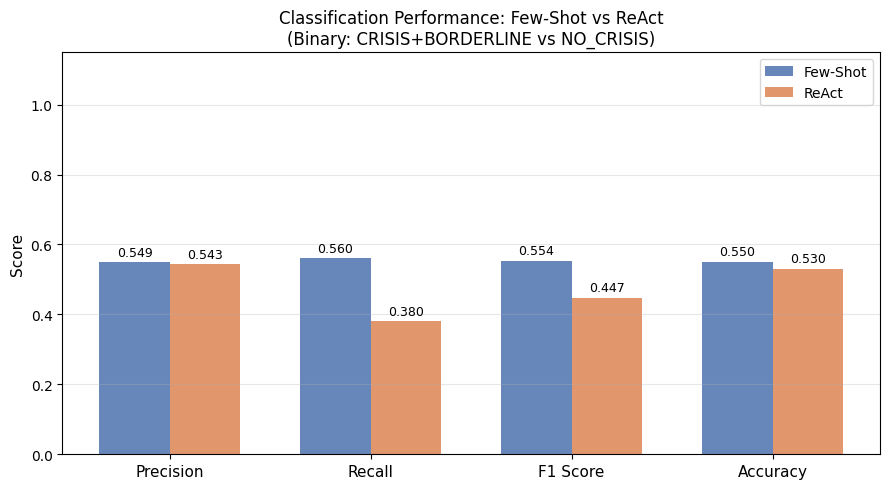

Plot saved.


In [44]:
# ─────────────────────────────────────────────────────────────
# PLOT 1 — Precision / Recall / F1 Bar Chart
# Side-by-side grouped bars for direct visual comparison.
# Values come directly from compute_metrics() — no hardcoding.
# ─────────────────────────────────────────────────────────────

metric_names = ["Precision", "Recall", "F1 Score", "Accuracy"]
fs_vals      = [fs_metrics["precision"], fs_metrics["recall"], fs_metrics["f1"], fs_metrics["accuracy"]]
react_vals   = [react_metrics["precision"], react_metrics["recall"], react_metrics["f1"], react_metrics["accuracy"]]

x    = range(len(metric_names))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_fs    = ax.bar([i - width/2 for i in x], fs_vals,    width, label="Few-Shot", color="#4C72B0", alpha=0.85)
bars_react = ax.bar([i + width/2 for i in x], react_vals, width, label="ReAct",    color="#DD8452", alpha=0.85)

# Annotate bars with exact values
for bar in bars_fs:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars_react:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(list(x))
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_ylim(0, 1.15)
ax.set_title("Classification Performance: Few-Shot vs ReAct\n(Binary: CRISIS+BORDERLINE vs NO_CRISIS)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/snapshots/plot1_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

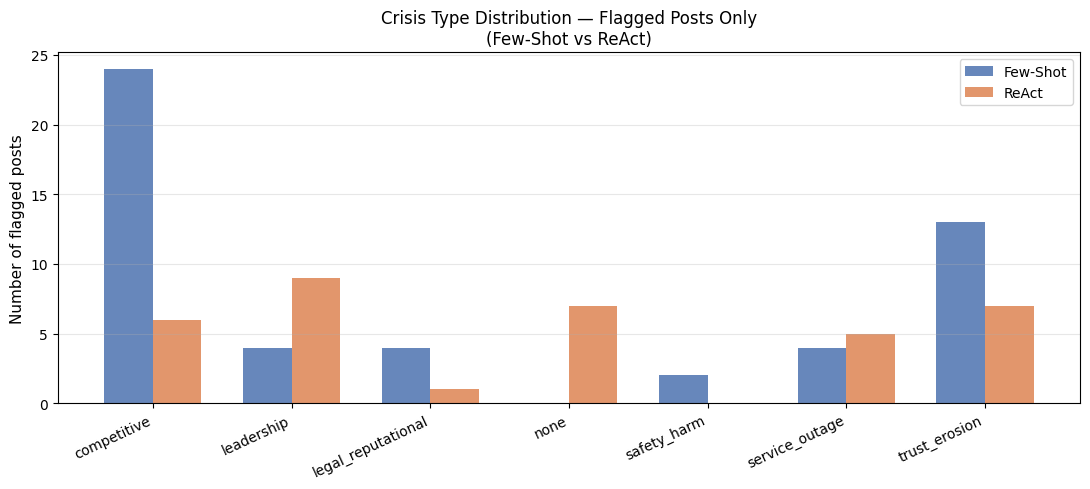

Plot saved.


In [45]:
# ─────────────────────────────────────────────────────────────
# PLOT 2 — Crisis Type Distribution
# Stacked bars showing which crisis types each technique
# identified. Values are computed dynamically from df_few_shot
# and df_react — not hardcoded.
# ─────────────────────────────────────────────────────────────

# Get all crisis types present across both techniques
all_types = sorted(set(df_few_shot["crisis_type"].unique()) | set(df_react["crisis_type"].unique()))

# Compute counts for flagged posts only (not NO_CRISIS)
fs_flagged    = df_few_shot[df_few_shot["label"].isin(["CRISIS", "BORDERLINE"])]
react_flagged = df_react[df_react["label"].isin(["CRISIS", "BORDERLINE"])]

fs_type_counts    = fs_flagged["crisis_type"].value_counts()
react_type_counts = react_flagged["crisis_type"].value_counts()

# Build aligned arrays for all types
fs_vals_type    = [fs_type_counts.get(t, 0)    for t in all_types]
react_vals_type = [react_type_counts.get(t, 0) for t in all_types]

x2 = range(len(all_types))

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar([i - width/2 for i in x2], fs_vals_type,    width, label="Few-Shot", color="#4C72B0", alpha=0.85)
ax.bar([i + width/2 for i in x2], react_vals_type, width, label="ReAct",    color="#DD8452", alpha=0.85)

ax.set_xticks(list(x2))
ax.set_xticklabels(all_types, rotation=25, ha="right", fontsize=10)
ax.set_ylabel("Number of flagged posts", fontsize=11)
ax.set_title("Crisis Type Distribution — Flagged Posts Only\n(Few-Shot vs ReAct)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/snapshots/plot2_crisis_type_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

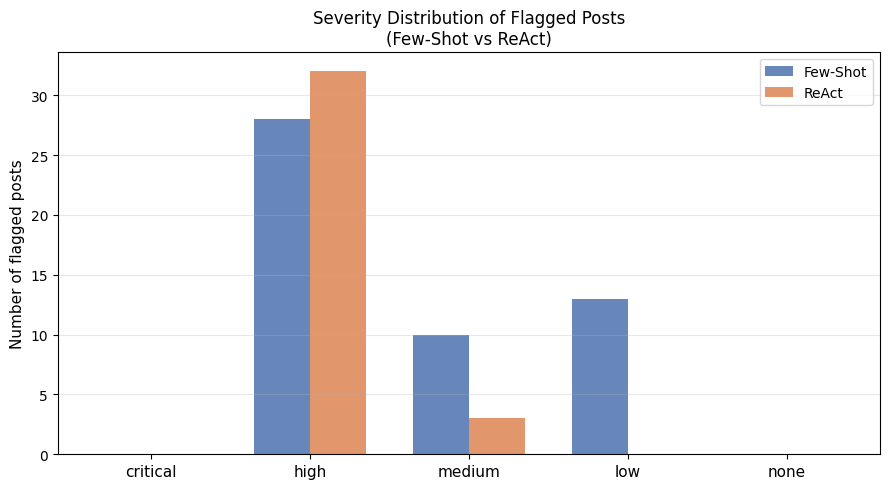

Plot saved.


In [33]:
# ─────────────────────────────────────────────────────────────
# PLOT 3 — Severity Distribution of Flagged Posts
# Do the techniques agree on what is critical vs low risk?
# A high proportion of "critical" from ReAct (due to upvote
# signal) vs "high" from few-shot illustrates their different
# reasoning approaches.
# ─────────────────────────────────────────────────────────────

severity_order = ["critical", "high", "medium", "low", "none"]

fs_sev    = fs_flagged["severity"].value_counts().reindex(severity_order, fill_value=0)
react_sev = react_flagged["severity"].value_counts().reindex(severity_order, fill_value=0)

x3 = range(len(severity_order))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar([i - width/2 for i in x3], fs_sev.values,    width, label="Few-Shot", color="#4C72B0", alpha=0.85)
ax.bar([i + width/2 for i in x3], react_sev.values, width, label="ReAct",    color="#DD8452", alpha=0.85)

ax.set_xticks(list(x3))
ax.set_xticklabels(severity_order, fontsize=11)
ax.set_ylabel("Number of flagged posts", fontsize=11)
ax.set_title("Severity Distribution of Flagged Posts\n(Few-Shot vs ReAct)", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data/snapshots/plot3_severity_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

In [46]:
# ─────────────────────────────────────────────────────────────
# AGREEMENT ANALYSIS
# Merge few-shot and react on post_id to find:
#   - Both agree CRISIS
#   - Few-shot only flagged
#   - ReAct only flagged
#   - Both agree NO_CRISIS
# Then print example disagreements for qualitative discussion.
# ─────────────────────────────────────────────────────────────

# Merge both results on post_id
df_merged = df_few_shot[["post_id", "label", "crisis_type", "severity", "ground_truth"]].merge(
    df_react[["post_id", "label", "crisis_type", "severity", "reach_risk"]],
    on="post_id",
    suffixes=("_fs", "_react")
)

# Binarise for agreement analysis
df_merged["fs_flagged"]    = df_merged["label_fs"].isin(["CRISIS", "BORDERLINE"])
df_merged["react_flagged"] = df_merged["label_react"].isin(["CRISIS", "BORDERLINE"])
df_merged["gt_flagged"]    = df_merged["ground_truth"] == "CRISIS"

# Four agreement categories — computed dynamically
both_crisis    = df_merged[df_merged["fs_flagged"] & df_merged["react_flagged"]]
fs_only        = df_merged[df_merged["fs_flagged"] & ~df_merged["react_flagged"]]
react_only     = df_merged[~df_merged["fs_flagged"] & df_merged["react_flagged"]]
both_no_crisis = df_merged[~df_merged["fs_flagged"] & ~df_merged["react_flagged"]]

print("=== AGREEMENT ANALYSIS ===")
print(f"Both flagged (CRISIS/BORDERLINE): {len(both_crisis):>3} posts")
print(f"Few-Shot only flagged:            {len(fs_only):>3} posts")
print(f"ReAct only flagged:               {len(react_only):>3} posts")
print(f"Both said NO_CRISIS:              {len(both_no_crisis):>3} posts")
print(f"Total posts:                      {len(df_merged):>3} posts")
print()

# Agreement rate on binary flagging decision
agreement_rate = (len(both_crisis) + len(both_no_crisis)) / len(df_merged)
print(f"Overall agreement rate:           {agreement_rate:.1%}")

=== AGREEMENT ANALYSIS ===
Both flagged (CRISIS/BORDERLINE):  29 posts
Few-Shot only flagged:             22 posts
ReAct only flagged:                 6 posts
Both said NO_CRISIS:               43 posts
Total posts:                      100 posts

Overall agreement rate:           72.0%


In [47]:
# ─────────────────────────────────────────────────────────────
# QUALITATIVE DISAGREEMENT EXAMPLES
# Show real posts where the two techniques diverged.
# These are the most analytically interesting cases and should
# be discussed in the report.
# ─────────────────────────────────────────────────────────────

# Enrich merged df with original post text
df_merged_full = df_merged.merge(
    df_eval[["id", "title", "text", "score", "subreddit"]],
    left_on="post_id", right_on="id",
    how="left"
)

def print_disagreements(subset: pd.DataFrame, label: str, n: int = 3) -> None:
    print(f"\n{'='*60}")
    print(f"DISAGREEMENT TYPE: {label}")
    print(f"{'='*60}")
    for _, row in subset.head(n).iterrows():
        print(f"\nPost ID:      {row['post_id']}")
        print(f"Subreddit:    r/{row['subreddit']} | Score: {row['score']}")
        print(f"Ground truth: {row['ground_truth']}")
        print(f"Few-Shot:     [{row['label_fs']}] type={row['crisis_type_fs']} sev={row['severity_fs']}")
        print(f"ReAct:        [{row['label_react']}] type={row['crisis_type_react']} sev={row['severity_react']} reach={row['reach_risk']}")
        print(f"Title:        {str(row.get('title', ''))[:100]}")


# Get disagreement subsets from df_merged_full
fs_only_full    = df_merged_full[df_merged_full["fs_flagged"] & ~df_merged_full["react_flagged"]]
react_only_full = df_merged_full[~df_merged_full["fs_flagged"] & df_merged_full["react_flagged"]]

print_disagreements(fs_only_full,    "Few-Shot flagged — ReAct did NOT")
print_disagreements(react_only_full, "ReAct flagged — Few-Shot did NOT")


DISAGREEMENT TYPE: Few-Shot flagged — ReAct did NOT

Post ID:      1sn3td3
Subreddit:    r/singularity | Score: 181
Ground truth: NO_CRISIS
Few-Shot:     [BORDERLINE] type=competitive sev=medium
ReAct:        [NO_CRISIS] type=none sev=low reach=medium
Title:        OpenAI continues to lose market share in GenAI website traffic, while Gemini, and Claude are gaining

Post ID:      1lkycad
Subreddit:    r/OpenAI | Score: 29
Ground truth: CRISIS
Few-Shot:     [BORDERLINE] type=competitive sev=high
ReAct:        [NO_CRISIS] type=leadership sev=high reach=medium
Title:        Sam Altman Publicly Confronts New York Times Journalists Over Lawsuit and User Privacy

Post ID:      1c5wtfy
Subreddit:    r/singularity | Score: 203
Ground truth: CRISIS
Few-Shot:     [BORDERLINE] type=competitive sev=low
ReAct:        [NO_CRISIS] type=none sev=low reach=medium
Title:        A monster of a paper by Stanford, a 500-page report on the 2024 state of AI

DISAGREEMENT TYPE: ReAct flagged — Few-Shot did NO

In [36]:
# ─────────────────────────────────────────────────────────────
# SUMMARY TABLE — for report / presentation use
# All values computed dynamically from the results above.
# ─────────────────────────────────────────────────────────────

# Compute avg tokens (approximation: chars / 4)
fs_avg_tokens    = df_few_shot["reasoning"].str.len().mean() / 4
react_avg_tokens = df_react["full_trace"].str.len().mean() / 4

summary_data = {
    "Dimension":          [
        "Precision", "Recall", "F1 Score", "Accuracy",
        "Total posts flagged", "CRISIS predictions", "BORDERLINE predictions",
        "Avg output tokens (approx)", "Uses metadata (score/subreddit)",
        "Provides reasoning trace",
    ],
    "Few-Shot": [
        fs_metrics["precision"], fs_metrics["recall"], fs_metrics["f1"], fs_metrics["accuracy"],
        fs_metrics["flagged_count"], fs_metrics["crisis_only"], fs_metrics["borderline"],
        f"{fs_avg_tokens:.0f}", "No", "No",
    ],
    "ReAct": [
        react_metrics["precision"], react_metrics["recall"], react_metrics["f1"], react_metrics["accuracy"],
        react_metrics["flagged_count"], react_metrics["crisis_only"], react_metrics["borderline"],
        f"{react_avg_tokens:.0f}", "Yes", "Yes",
    ],
}

df_summary = pd.DataFrame(summary_data)
print("=== TECHNIQUE COMPARISON SUMMARY ===")
print(df_summary.to_string(index=False))

=== TECHNIQUE COMPARISON SUMMARY ===
                      Dimension Few-Shot  ReAct
                      Precision    0.549  0.543
                         Recall     0.56   0.38
                       F1 Score    0.554  0.447
                       Accuracy     0.55   0.53
            Total posts flagged       51     35
             CRISIS predictions       25     35
         BORDERLINE predictions       26      0
     Avg output tokens (approx)       25    548
Uses metadata (score/subreddit)       No    Yes
       Provides reasoning trace       No    Yes


### Analysis

**Few-Shot strengths:** Consistent and concise on text-obvious crisis posts. The in-context examples effectively anchor classification to the Reddit domain. Lower token usage makes it suitable as a fast first-pass filter over large post volumes.

**Few-Shot weaknesses:** Classifies based on text content only — cannot incorporate post metadata (score, subreddit). Performance on borderline cases depends heavily on how representative the five examples are. If a novel crisis type not covered by examples appears, classification degrades.

**ReAct strengths:** Explicit multi-signal reasoning incorporates upvote score and subreddit context, which few-shot ignores. The reasoning trace is auditable — a brand analyst can read exactly *why* a post was flagged, making false positives easy to identify and dismiss. Better suited for borderline posts where text tone is ambiguous.

**ReAct weaknesses:** Significantly higher token usage due to the reasoning chain. Structured output (Answer: JSON) is harder to parse reliably — the model sometimes produces the Answer block in a non-standard format. Not ideal for high-volume batch processing.

**Recommended pipeline design:** Use Few-Shot as a fast batch pre-filter (flag or clear all 590 posts). Pass only flagged posts to ReAct for deep analysis, reasoning trace generation, and severity scoring. This combines both techniques' strengths while controlling inference cost.

---
## Section 6 — Crisis Report Generation

This section uses the ReAct results to generate a **structured executive crisis brief** — the final output that a brand analyst would receive. This is the integration point between the prompting module and the report generation / dashboard modules.

The brief is generated using a synthesis prompt over the top flagged posts from ReAct's output.

In [48]:
# ─────────────────────────────────────────────────────────────
# CRISIS BRIEF GENERATION
# Selects the top-N highest severity posts flagged by ReAct
# and synthesises them into an executive summary.
# Severity is ranked: critical > high > medium > low > none.
# Within the same severity, higher score posts rank first.
# ─────────────────────────────────────────────────────────────

SEVERITY_RANK = {"critical": 4, "high": 3, "medium": 2, "low": 1, "none": 0}
TOP_N_FOR_BRIEF = 10


def generate_crisis_brief(df_react_results: pd.DataFrame, df_original: pd.DataFrame, top_n: int = TOP_N_FOR_BRIEF) -> str:
    """
    Generate an executive crisis brief from ReAct flagged posts.

    Args:
        df_react_results: DataFrame of ReAct outputs.
        df_original:      Full original dataset for score lookup.
        top_n:            Number of top-severity posts to include.

    Returns:
        Generated brief as a string.
    """
    # Filter to flagged posts only
    flagged = df_react_results[df_react_results["label"].isin(["CRISIS", "BORDERLINE"])].copy()

    if len(flagged) == 0:
        return "No crisis signals detected in the current dataset window."

    # Rank by severity then score
    flagged["severity_rank"] = flagged["severity"].map(SEVERITY_RANK).fillna(0)
    flagged = flagged.sort_values(["severity_rank", "score"], ascending=[False, False])

    top_posts = flagged.head(top_n)

    # Build the evidence block for the prompt
    evidence_lines = []
    for _, row in top_posts.iterrows():
        evidence_lines.append(
            f"- [{row['severity'].upper()}] [{row['crisis_type']}] "
            f"r/{row['subreddit']} | {row['score']} upvotes | "
            f"{row.get('key_signal', row.get('reasoning', ''))[:120]}"
        )
    evidence_block = "\n".join(evidence_lines)

    prompt = f"""You are a senior brand analyst preparing an executive briefing for OpenAI's communications team.

Based on the following Reddit signals flagged by crisis analysis, write a concise executive crisis brief.
The brief must include:
1. Overall threat level (Critical / High / Medium / Low)
2. Top 2-3 specific issues identified
3. One recommended immediate action for the brand team
Keep the brief under 150 words. Be direct and specific.

Flagged signals ({len(flagged)} total, showing top {top_n}):
{evidence_block}

Executive Crisis Brief:"""

    return cached_llm_call(prompt, technique="crisis_brief", cache=llm_cache)


# Generate the brief using full react results and original data for score
df_react_with_score = df_react.merge(
    df_eval[["id", "score", "subreddit"]].rename(columns={"id": "post_id"}),
    on="post_id", how="left", suffixes=("", "_orig")
)
# Use original score if react df doesn't have it
if "score_orig" in df_react_with_score.columns:
    df_react_with_score["score"] = df_react_with_score["score_orig"].fillna(df_react_with_score["score"])

crisis_brief = generate_crisis_brief(df_react_with_score, df_eval)

print("=" * 60)
print("OPENAI BRAND CRISIS BRIEF")
print("Generated by ReAct Prompting Pipeline")
print("=" * 60)
print(crisis_brief)

OPENAI BRAND CRISIS BRIEF
Generated by ReAct Prompting Pipeline
**Executive Crisis Brief**

**Threat Level:** High

**Top Issues Identified:**
1. Sudden model deletions by OpenAI (service_outage)
2. Legal actions threatening key figures (legal_reputational, leadership)
3. Users' trust erosion due to potential misuse and unethical practices (trust_erosion)

**Immediate Action Recommended:**
Implement a public relations strategy focused on transparency and re-establishing ethical standards in collaboration with legal teams to address the legal threats and reassure users about OpenAI's commitment to user safety and ethics.


In [49]:
# ─────────────────────────────────────────────────────────────
# CRISIS DASHBOARD SUMMARY TABLE
# Quick at-a-glance table of top flagged posts for the
# dashboard / report. Shows post title, subreddit, score,
# crisis type, and severity — all from dynamic outputs.
# ─────────────────────────────────────────────────────────────

# Merge react results with original post titles
df_dashboard = df_react_with_score[df_react_with_score["label"].isin(["CRISIS", "BORDERLINE"])].merge(
    df_eval[["id", "title"]].rename(columns={"id": "post_id"}),
    on="post_id", how="left"
).copy()

df_dashboard["severity_rank"] = df_dashboard["severity"].map(SEVERITY_RANK).fillna(0)
df_dashboard = df_dashboard.sort_values(["severity_rank", "score"], ascending=[False, False])

display_cols = ["post_id", "title", "subreddit", "score", "label", "crisis_type", "severity", "reach_risk"]
available_cols = [c for c in display_cols if c in df_dashboard.columns]

df_display = df_dashboard[available_cols].head(15).copy()
if "title" in df_display.columns:
    df_display["title"] = df_display["title"].str[:60]

print(f"Top {len(df_display)} Flagged Posts (ReAct):")
print(df_display.to_string(index=False))

Top 15 Flagged Posts (ReAct):
post_id                                                        title   subreddit  score  label        crisis_type severity reach_risk
1mkobei OpenAI just pulled the biggest bait-and-switch in AI history     ChatGPT  10825 CRISIS     service_outage     high       high
14f35cu OpenAI quietly lobbied for weaker AI regulations while publi     ChatGPT   1762 CRISIS         leadership     high       high
1sxeiiy If Elon Musk wins the OpenAI lawsuit… Sam Altman & others be     ChatGPT   1671 CRISIS legal_reputational     high       high
1rhp7tz               Every promise Sam Altman broke — with receipts      OpenAI   1255 CRISIS         leadership     high       high
1ljeqg0 Elon Musk claims he ‘does not use a computer’ in OpenAI laws      OpenAI   1005 CRISIS      trust_erosion     high       high
1hm6d3h "The rumored ♾ (infinite) Memory for ChatGPT is real. The ne singularity    934 CRISIS      trust_erosion     high       high
1gqez9g The speed with which Elo

---
## Section 7 — Pipeline Export Function

This section defines the clean interface that the rest of the system (RAG module, dashboard, report generation) calls to get prompting-based crisis analysis results.

Calling `run_prompting_pipeline(posts)` returns a standardised list of dicts with consistent keys regardless of which technique is used internally.

In [50]:
# ─────────────────────────────────────────────────────────────
# PIPELINE EXPORT FUNCTION
# This is the external API for this notebook.
# Other notebooks import and call run_prompting_pipeline().
#
# Design:
#   - technique="both"  → few-shot pre-filter, react for flagged posts
#   - technique="few_shot" → few-shot only (fast, lower cost)
#   - technique="react"    → react only (interpretable, slower)
#
# All calls go through the shared disk cache.
# ─────────────────────────────────────────────────────────────

def run_prompting_pipeline(
    posts: list[dict],
    technique: str = "both",
    verbose: bool = False,
) -> list[dict]:
    """
    Run prompting-based crisis detection over a list of Reddit posts.

    Args:
        posts:     List of post dicts. Each must have keys:
                   'id', 'text', 'subreddit', 'score'.
        technique: 'few_shot' | 'react' | 'both'
                   'both' runs few-shot first, then react only on
                   posts flagged as CRISIS or BORDERLINE.
        verbose:   If True, print progress.

    Returns:
        List of dicts, one per input post, with keys:
            id, label, crisis_type, severity,
            reasoning, technique_used,
            reach_risk (react only, else 'n/a'),
            full_trace (react only, else None)
    """
    cache = load_cache()
    results = []

    for post in tqdm(posts, disable=not verbose, desc=f"Prompting [{technique}]"):
        post_id   = post["id"]
        text      = post["text"]
        subreddit = post.get("subreddit", "unknown")
        score     = post.get("score", 0)

        result = {
            "id":             post_id,
            "label":          "NO_CRISIS",
            "crisis_type":    "none",
            "severity":       "none",
            "reasoning":      "",
            "technique_used": "",
            "reach_risk":     "n/a",
            "full_trace":     None,
        }

        if technique in ("few_shot", "both"):
            fs_prompt = build_few_shot_prompt(text)
            fs_raw    = cached_llm_call(fs_prompt, technique="few_shot", cache=cache)
            fs_parsed = parse_json_response(fs_raw, technique="few_shot")
            result.update({
                "label":          fs_parsed["label"],
                "crisis_type":    fs_parsed["crisis_type"],
                "severity":       fs_parsed["severity"],
                "reasoning":      fs_parsed["reasoning"],
                "technique_used": "few_shot",
            })

        # In 'both' mode, only run react on posts that few-shot flagged
        run_react = (
            technique == "react"
            or (technique == "both" and result["label"] in {"CRISIS", "BORDERLINE"})
        )

        if run_react:
            r_prompt = build_react_prompt(text, subreddit, score)
            r_raw    = cached_llm_call(r_prompt, technique="react", cache=cache)
            r_parsed = parse_react_response(r_raw)
            result.update({
                "label":          r_parsed["label"],
                "crisis_type":    r_parsed["crisis_type"],
                "severity":       r_parsed["severity"],
                "reasoning":      r_parsed["reasoning"],
                "reach_risk":     r_parsed["reach_risk"],
                "full_trace":     r_parsed["full_trace"],
                "technique_used": "react" if technique == "react" else "few_shot→react",
            })

        results.append(result)

    return results


print("✅ run_prompting_pipeline() defined")
print()
print("Usage:")
print("  from A3_Prompting_Techniques import run_prompting_pipeline")
print("  results = run_prompting_pipeline(posts, technique='both')")
print()
print("Output keys per post:")
print("  id, label, crisis_type, severity, reasoning, technique_used, reach_risk, full_trace")

✅ run_prompting_pipeline() defined

Usage:
  from A3_Prompting_Techniques import run_prompting_pipeline
  results = run_prompting_pipeline(posts, technique='both')

Output keys per post:
  id, label, crisis_type, severity, reasoning, technique_used, reach_risk, full_trace


In [51]:
# ─────────────────────────────────────────────────────────────
# SMOKE TEST — run the pipeline on 5 posts to verify it works
# end-to-end before other notebooks depend on it.
# ─────────────────────────────────────────────────────────────

test_posts = df_eval[["id", "text", "subreddit", "score"]].head(5).to_dict("records")
test_results = run_prompting_pipeline(test_posts, technique="both", verbose=True)

print("\n=== SMOKE TEST RESULTS ===")
for r in test_results:
    print(f"  {r['id']} → [{r['label']}] [{r['crisis_type']}] [{r['severity']}] via {r['technique_used']}")

print("\n✅ Pipeline smoke test passed" if len(test_results) == 5 else "❌ Unexpected result count")

Prompting [both]: 100%|██████████| 5/5 [00:00<00:00, 7617.70it/s]


=== SMOKE TEST RESULTS ===
  1rl2ygn → [NO_CRISIS] [none] [none] via few_shot
  1sn3td3 → [NO_CRISIS] [none] [low] via few_shot→react
  1jj4cjl → [NO_CRISIS] [none] [none] via few_shot
  1lkycad → [NO_CRISIS] [leadership] [high] via few_shot→react
  1shtaau → [CRISIS] [service_outage] [high] via few_shot→react

✅ Pipeline smoke test passed


In [52]:
# ─────────────────────────────────────────────────────────────
# SAVE RESULTS TO DISK
# Serialise both technique results and the combined eval
# dataframe for the report and downstream modules to load.
# ─────────────────────────────────────────────────────────────

output_dir = Path("../data/snapshots")
output_dir.mkdir(parents=True, exist_ok=True)

# Save few-shot results
df_few_shot.to_json(output_dir / "prompting_few_shot_results.json", orient="records", indent=2)

# Save react results (drop full_trace to keep file manageable)
df_react.drop(columns=["full_trace"], errors="ignore").to_json(
    output_dir / "prompting_react_results.json", orient="records", indent=2
)

# Save merged comparison
df_merged.to_json(output_dir / "prompting_comparison.json", orient="records", indent=2)

# Save crisis brief as text
brief_path = output_dir / "crisis_brief.txt"
brief_path.write_text(crisis_brief, encoding="utf-8")

print("✅ Results saved:")
print(f"   {output_dir}/prompting_few_shot_results.json")
print(f"   {output_dir}/prompting_react_results.json")
print(f"   {output_dir}/prompting_comparison.json")
print(f"   {output_dir}/crisis_brief.txt")
print(f"   {output_dir}/llm_cache.json  ({len(llm_cache)} entries)")
print(f"   {output_dir}/plot1_metrics_comparison.png")
print(f"   {output_dir}/plot2_crisis_type_distribution.png")
print(f"   {output_dir}/plot3_severity_distribution.png")

✅ Results saved:
   ..\data\snapshots/prompting_few_shot_results.json
   ..\data\snapshots/prompting_react_results.json
   ..\data\snapshots/prompting_comparison.json
   ..\data\snapshots/crisis_brief.txt
   ..\data\snapshots/llm_cache.json  (305 entries)
   ..\data\snapshots/plot1_metrics_comparison.png
   ..\data\snapshots/plot2_crisis_type_distribution.png
   ..\data\snapshots/plot3_severity_distribution.png
